In [ ]:
# Install nerfstudio and dependencies
!pip install nerfstudio
!ns-install-cli

# Verify installation and GPU access
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# 1. Purge the dirty installations
!pip uninstall -y numpy opencv-python opencv-python-headless opencv-contrib-python

# 2. Reinstall strict 1.x compatible versions
!pip install -q "numpy<2.0.0" "opencv-python-headless<4.10.0" "opencv-python<4.10.0" "opencv-contrib-python<4.10.0"

In [ ]:
!pip install -q "transformers<4.40.0"

In [ ]:
import os
import shutil

input_base = '/kaggle/input'
working_dir = '/kaggle/working/dataset'

print(f"Scanning {input_base} for transforms.json...")

transform_path = None
for root, dirs, files in os.walk(input_base):
    for file in files:
        if file in ['transforms.json', 'transform.json']:
            transform_path = os.path.join(root, file)
            break
    if transform_path:
        break

if transform_path is None:
    print("❌ CRITICAL ERROR: transforms.json not found!")
else:
    source_dir = os.path.dirname(transform_path)
    print(f"✅ Found data at: {source_dir}")
    
    if os.path.exists(working_dir):
        shutil.rmtree(working_dir)
        
    print(f"Copying files to {working_dir}...")
    shutil.copytree(source_dir, working_dir)
    print("\n✅ Copy complete! Contents:")
    os.system(f"ls {working_dir}")

In [ ]:
print("🚀 Training started! Monitor with: !tail -n 20 /kaggle/working/training_log.txt")

!MAX_JOBS=4 ns-train splatfacto \
    --output-dir /kaggle/working/outputs \
    --max-num-iterations 30000 \
    --vis tensorboard \
    --pipeline.model.camera-optimizer.mode off \
    --optimizers.means.optimizer.lr 0.0016 \
    --optimizers.scales.optimizer.lr 0.005 \
    nerfstudio-data \
    --data /kaggle/working/dataset \
    --orientation-method none \
    --center-method none \
    --auto-scale-poses False > /kaggle/working/training_log.txt 2>&1

print("🎉 Training Complete!")


In [ ]:
!tail -n 20 /kaggle/working/training_log.txt

In [ ]:
import glob
import os

print("🔧 Patching PyTorch 2.6 security defaults...")
eval_utils_path = "/usr/local/lib/python3.12/dist-packages/nerfstudio/utils/eval_utils.py"

if os.path.exists(eval_utils_path):
    with open(eval_utils_path, 'r') as f:
        content = f.read()
    content = content.replace(
        'loaded_state = torch.load(load_path, map_location="cpu")',
        'loaded_state = torch.load(load_path, map_location="cpu", weights_only=False)'
    )
    with open(eval_utils_path, 'w') as f:
        f.write(content)
    print("✅ Patch applied successfully!\n")

config_paths = glob.glob("/kaggle/working/outputs/*/splatfacto/*/config.yml")

if config_paths:
    latest_config = max(config_paths, key=os.path.getctime)
    os.environ['MY_CONFIG'] = latest_config
    
    !ns-eval --load-config $MY_CONFIG --output-path /kaggle/working/evaluation_results.json
    
    if os.path.exists('/kaggle/working/evaluation_results.json'):
        with open('/kaggle/working/evaluation_results.json', 'r') as f:
            print("\n✅ --- EVALUATION RESULTS --- ✅")
            print(f.read())
else:
    print("Error: config.yml not found.")

In [ ]:
import glob, os, subprocess

config_paths = glob.glob("/kaggle/working/outputs/*/splatfacto/*/config.yml")
if not config_paths:
    raise RuntimeError("No config.yml — run training Cell 2 first.")
latest_config = max(config_paths, key=os.path.getctime)

export_dir = "/kaggle/working/exports"
os.makedirs(export_dir, exist_ok=True)

print("Exporting Gaussian Splat PLY...")
result = subprocess.run(
    f"ns-export gaussian-splat --load-config {latest_config} --output-dir {export_dir}",
    shell=True, capture_output=True, text=True)
print(result.stdout[-1000:] if result.stdout else "")
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

ply_files = glob.glob(f"{export_dir}/*.ply")
if ply_files:
    print(f"✅ {ply_files[0]}  ({os.path.getsize(ply_files[0])/1e6:.1f} MB)")
else:
    print("❌ No PLY found")


In [ ]:
import os, sys, subprocess

GSAM_DIR    = "/kaggle/working/Grounded-Segment-Anything"
WEIGHTS_DIR = f"{GSAM_DIR}/weights"
DINO_W = f"{WEIGHTS_DIR}/groundingdino_swint_ogc.pth"
SAM_W  = f"{WEIGHTS_DIR}/sam_vit_h_4b8939.pth"

def run(cmd, **kw):
    """Run a shell command, print output, raise on failure."""
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, **kw)
    if r.stdout: print(r.stdout[-2000:])
    if r.returncode != 0:
        print("STDERR:", r.stderr[-1000:])
        raise RuntimeError(f"Command failed: {cmd}")
    return r

# 1. Clone repo
if not os.path.exists(GSAM_DIR):
    print("Cloning Grounded-Segment-Anything...")
    run(f"git clone https://github.com/IDEA-Research/Grounded-Segment-Anything.git {GSAM_DIR}")

# 2. Install GroundingDINO — try pre-built wheel first, fall back to source
print("\nInstalling GroundingDINO...")
dino_installed = False

# Try 1: pre-built wheel (no CUDA compilation needed)
try:
    r = subprocess.run(
        "pip install groundingdino-py",
        shell=True, capture_output=True, text=True)
    if r.returncode == 0:
        import groundingdino
        print("✅ GroundingDINO installed via pip wheel")
        dino_installed = True
    else:
        print("pip wheel failed, trying source build...")
        print(r.stderr[-500:])
except Exception as e:
    print(f"wheel attempt error: {e}")

# Try 2: source build with explicit CUDA flags
if not dino_installed:
    try:
        env = os.environ.copy()
        env.update({
            "AM_I_DOCKER": "False",
            "BUILD_WITH_CUDA": "True",
            "CUDA_HOME": "/usr/local/cuda",
            "TORCH_CUDA_ARCH_LIST": "7.0;7.5;8.0;8.6",
        })
        r = subprocess.run(
            f"pip install -e {GSAM_DIR}/GroundingDINO 2>&1 | tail -30",
            shell=True, capture_output=True, text=True, env=env)
        print(r.stdout)
        if r.returncode == 0:
            print("✅ GroundingDINO installed from source")
            dino_installed = True
        else:
            print("Source build also failed.")
    except Exception as e:
        print(f"Source build error: {e}")

# Try 3: install from a known-good fork that pre-packages wheels
if not dino_installed:
    try:
        run("pip install git+https://github.com/IDEA-Research/GroundingDINO.git")
        print("✅ GroundingDINO installed from GitHub")
        dino_installed = True
    except Exception as e:
        print(f"GitHub install failed: {e}")

if not dino_installed:
    raise RuntimeError(
        "GroundingDINO could not be installed.\n"
        "MANUAL FIX: In a new cell run:\n"
        "  !pip install groundingdino-py\n"
        "and share the full error output.")

# 3. Install SAM
print("\nInstalling SAM...")
run("pip install git+https://github.com/facebookresearch/segment-anything.git")
print("✅ SAM installed")

# 4. Download weights
os.makedirs(WEIGHTS_DIR, exist_ok=True)
if not os.path.exists(DINO_W) or os.path.getsize(DINO_W) < 100_000_000:
    print("\nDownloading GroundingDINO weights (~660 MB)...")
    run(f"wget -q --tries=3 -O {DINO_W} "
        "https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth")
    print(f"  Size: {os.path.getsize(DINO_W)/1e6:.0f} MB")

if not os.path.exists(SAM_W) or os.path.getsize(SAM_W) < 500_000_000:
    print("\nDownloading SAM ViT-H weights (~2.4 GB)...")
    run(f"wget -q --tries=3 -O {SAM_W} "
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth")
    print(f"  Size: {os.path.getsize(SAM_W)/1e6:.0f} MB")

print("\n✅ All setup complete. Run Cell 7 for OBB detection.")


In [ ]:
import subprocess, sys

# Fix numpy/torch binary incompatibility
# Must run before ANY torch or numpy import
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall",
                "numpy==1.26.4"], check=True)

# Force reload numpy in this session
import importlib, numpy
importlib.reload(numpy)
print(f"numpy version: {numpy.__version__}")
print("✅ Restart kernel now and re-run from Cell 10 onwards.")
print("   (This cell only needs to run once to fix the environment)")


In [35]:
# ── CELL 10: Semantic 3D OBB Detection (final) ───────────────────────────────
import os, sys, json, glob
import numpy as np
import subprocess
import torch

subprocess.run(["pip","install","-q","plyfile"], check=True)
from plyfile import PlyData
from groundingdino.util.inference import load_model, load_image, predict

GSAM_DIR    = "/kaggle/working/Grounded-Segment-Anything"
DINO_W      = f"{GSAM_DIR}/weights/groundingdino_swint_ogc.pth"
DATASET_DIR = "/kaggle/working/dataset"
TRANSFORMS  = os.path.join(DATASET_DIR, "transforms.json")
OUTPUT_JSON = "/kaggle/working/FINAL_SUBMISSION.json"
EXPORT_DIR  = "/kaggle/working/exports"
sys.path.extend([GSAM_DIR, f"{GSAM_DIR}/GroundingDINO"])

GT_VGA_C = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])

ENTITY_CAPTIONS = [
    ("vga socket",        ["vga socket", "vga port", "vga connector"]),
    ("power socket",      ["power socket", "power connector", "iec socket", "power inlet"]),
    ("ethernet socket",   ["ethernet socket", "ethernet port", "rj45 port"]),
    ("usb port",          ["usb port", "usb socket"]),
    ("hdmi port",         ["hdmi port", "hdmi socket"]),
    ("audio jack",        ["audio jack", "headphone jack", "3.5mm jack"]),
    ("monitor stand",     ["monitor stand", "display stand"]),
    ("keyboard",          ["keyboard"]),
]

THRESHOLDS = {
    "keyboard":        0.15,
    "monitor stand":   0.15,
    "default":         0.20,
}

PHYSICAL_HALF_EXTENTS = {
    "vga_socket":      [0.0354, 0.0118, 0.0061],  
    "power_socket":    [0.0319, 0.0250, 0.0182],  
    "ethernet_socket": [0.0188, 0.0154, 0.0125],  
    "usb_port":        [0.0159, 0.0074, 0.0051],  
    "hdmi_port":       [0.0158, 0.0072, 0.0050],  
    "audio_jack":      [0.0159, 0.0068, 0.0068],  
    "monitor_stand":   [0.1500, 0.0800, 0.0300],
    "keyboard":        [0.1500, 0.0650, 0.0050],
}

RAY_CONE_DEG = 1.0
DEDUP_R      = 0.05
CLUSTER_R    = 0.03

with open(TRANSFORMS) as f:
    tr = json.load(f)
fl_x, fl_y, cx_k, cy_k = tr["fl_x"], tr["fl_y"], tr["cx"], tr["cy"]

cam_positions = np.array([f["transform_matrix"] for f in tr["frames"]])[:,:3,3]
CAM_CENTER    = cam_positions.mean(0)
print(f"Camera centroid: {CAM_CENTER.round(4)}")


def load_scene_xyz(export_dir):
    ply = glob.glob(f"{export_dir}/*.ply")
    if not ply:
        raise FileNotFoundError(f"No PLY in {export_dir}. Run Cell 7 first.")
    v = PlyData.read(ply[0])["vertex"]
    xyz = np.stack([np.array(v["x"], np.float32),
                    np.array(v["y"], np.float32),
                    np.array(v["z"], np.float32)], axis=1).astype(np.float64)
    if "opacity" in v.data.dtype.names:
        sig = 1.0 / (1.0 + np.exp(-np.array(v["opacity"], np.float32)))
        xyz = xyz[sig > 0.05]
    print(f"PLY: {len(xyz):,} pts")
    return xyz

xyz = load_scene_xyz(EXPORT_DIR)

def ray_cone_points(box_cx, box_cy, c2w_opengl):
    c2w = c2w_opengl.copy()
    c2w[:, 1:3] *= -1.0
    w2c = np.linalg.inv(c2w)
    p = (w2c @ np.hstack([xyz, np.ones((len(xyz), 1))]).T).T[:, :3]
    fwd = p[:, 2] > 0.05
    pf = p[fwd]
    if not len(pf):
        return np.zeros((0, 3))
    ray = np.array([(box_cx - cx_k) / fl_x, (box_cy - cy_k) / fl_y, 1.0])
    ray /= np.linalg.norm(ray)
    pd = pf / np.linalg.norm(pf, axis=1, keepdims=True)
    ang = np.degrees(np.arccos(np.clip(pd @ ray, -1, 1)))
    return xyz[np.where(fwd)[0][ang < RAY_CONE_DEG]]

def find_center(pts_all, placed_centers):
    if not pts_all: return None
    pts = np.vstack(pts_all)
    
    # 1. Deduplication (Respect established anchors)
    for pc in placed_centers:
        pts = pts[np.linalg.norm(pts - pc, axis=1) >= DEDUP_R]
    if len(pts) < 5: return None
        
    # 2. Voxelize
    coords = np.round(pts / 0.015).astype(int)
    unique_coords, counts = np.unique(coords, axis=0, return_counts=True)
    
    # 3. Filter noise
    valid_mask = counts >= 5
    if valid_mask.sum() == 0:
        valid_mask = counts >= 1  
        
    valid_coords = unique_coords[valid_mask]
    voxel_centers = valid_coords * 0.015
    
    # 4. RESTORE SCENE BOUNDS (Prevents X-Raying into the wall)
    in_scene = np.linalg.norm(voxel_centers - CAM_CENTER, axis=1) < CAM_RADIUS * 1.5
    if in_scene.sum() > 0:
        valid_coords = valid_coords[in_scene]
        voxel_centers = voxel_centers[in_scene]

    # 5. RESTORE FIRST-SURFACE ANCHORING (Snaps exactly to the metal faceplate)
    best_idx = np.argmin(np.linalg.norm(voxel_centers - CAM_CENTER, axis=1))
    best = valid_coords[best_idx]
    
    # 6. Iterative recentering
    mask = np.all(coords == best, axis=1)
    center = pts[mask].mean(0)
    
    for _ in range(3):
        m = np.linalg.norm(pts - center, axis=1) < CLUSTER_R
        if m.sum() < 3: break
        center = pts[m].mean(0)
        
    return center

def get_robust_obb(pts_all, center, entity):
    pts = np.vstack(pts_all)
    is_large = "keyboard" in entity or "stand" in entity
    clip_r = 0.25 if is_large else 0.08
    
    local = pts[np.linalg.norm(pts - center, axis=1) < clip_r]
    if len(local) < 5:
        local = pts

    # Allow PCA to find the true rotation of the PC tower for tight IoU
    ev, evec = np.linalg.eigh(np.cov(local - local.mean(0), rowvar=False))
    R = evec[:, np.argsort(ev)[::-1]]
    if np.linalg.det(R) < 0:
        R[:, 2] *= -1

    # Apply physical dimensions
    ekey = entity.replace(" ", "_")
    physical = np.array(PHYSICAL_HALF_EXTENTS.get(ekey, [0.02, 0.01, 0.005]))

    # Compute IQR extents
    proj = (local - center) @ R
    p5, p95 = np.percentile(proj, 5, axis=0), np.percentile(proj, 95, axis=0)
    iqr_ext = (p95 - p5) / 2.0

    # Ensure box doesn't collapse or bloat
    half_ext = np.clip(
        np.maximum(iqr_ext, physical),
        physical * 0.5,
        physical * 2.0
    )

    return center, R, half_ext

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
dino = load_model(
    f"{GSAM_DIR}/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py",
    DINO_W)

entity_data = {}
for name, captions in ENTITY_CAPTIONS:
    print(f"\n🔍 [{name}]  captions={captions}")
    thr = THRESHOLDS.get(name, THRESHOLDS["default"])
    pts_all = []
    det_count = 0
    for frame in tr["frames"]:
        img_path = os.path.join(DATASET_DIR, frame["file_path"])
        if not os.path.exists(img_path): continue
        img_src, img_t = load_image(img_path)
        H, W = img_src.shape[:2]
        best_box, best_logit = None, -1.0
        for cap in captions:
            boxes, logits, _ = predict(
                model=dino, image=img_t, caption=cap,
                box_threshold=thr, text_threshold=thr)
            if len(boxes) and logits.max().item() > best_logit:
                best_logit = logits.max().item()
                best_box = boxes[logits.argmax()]
        if best_box is None: continue
        det_count += 1
        pts = ray_cone_points(
            best_box[0].item() * W, best_box[1].item() * H,
            np.array(frame["transform_matrix"]))
        if len(pts):
            pts_all.append(pts)
            print(f"   {os.path.basename(img_path)}: {len(pts)} pts  logit={best_logit:.2f}")
    print(f"   Detections: {det_count}/{len(tr['frames'])}")
    entity_data[name] = pts_all

placed_centers = []
results = []

entity_names = [e[0] for e in ENTITY_CAPTIONS]
vga_first = ["vga socket"] + [
    e for e in sorted(entity_names, key=lambda e: -len(entity_data.get(e, [])))
    if e != "vga socket"
]

for name in vga_first:
    pts_all = entity_data.get(name, [])
    if not pts_all:
        print(f"\n⚠️  [{name}] no detections — skipping")
        continue
        
    center = find_center(pts_all, placed_centers)
    
    if center is None and name == "keyboard":
        all_pts = np.vstack(pts_all)
        valid_pts = all_pts[all_pts[:, 1] < 0.8]
        if len(valid_pts) >= 5:
            center = valid_pts.mean(0)
            
    if center is None:
        print(f"\n⚠️  [{name}] center finding failed — skipping")
        continue
        
    c_final, R, half_ext = get_robust_obb(pts_all, center, name)
    placed_centers.append(center)
    
    results.append({
        "entity": name.replace(" ", "_"),
        "obb": {
            "center":   c_final.tolist(),
            "extent":   half_ext.tolist(),
            "rotation": R.tolist()
        }
    })
    
    ext_mm = [round(e * 1000, 1) for e in half_ext]
    print(f"\n  ✅ [{name}]  center={c_final.round(4)}  ext={ext_mm}mm")
    if name == "vga socket":
        err = np.linalg.norm(c_final - GT_VGA_C)
        ok = "✅ PASS" if err < 0.15 else "❌ FAIL"
        print(f"  VGA error: {err*100:.1f}cm  {ok}")

with open(OUTPUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"\n✅ Saved {len(results)} entities → {OUTPUT_JSON}")

vga = next((e for e in results if e["entity"] == "vga_socket"), None)
if vga:
    c = np.array(vga["obb"]["center"])
    e = np.linalg.norm(c - GT_VGA_C)
    ok = "✅ PASS" if e < 0.15 else "❌ FAIL"
    print(f"VGA: {e*100:.2f}cm  {ok}")
    print(f"   Predicted: {c.round(4)}")
    print(f"   GT:        {GT_VGA_C.round(4)}")

Camera centroid: [ 0.3813 -0.2799  0.8267]
PLY: 219,308 pts
Device: cuda
final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



🔍 [vga socket]  captions=['vga socket', 'vga port', 'vga connector']


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:977: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args

   frame_000319.png: 171 pts  logit=0.53
   frame_000333.png: 173 pts  logit=0.67
   frame_000353.png: 113 pts  logit=0.78
   frame_000359.png: 208 pts  logit=0.52
   frame_000365.png: 159 pts  logit=0.56
   frame_000371.png: 77 pts  logit=0.53
   frame_000390.png: 73 pts  logit=0.54
   frame_000400.png: 51 pts  logit=0.52
   frame_000426.png: 389 pts  logit=0.60
   frame_000449.png: 319 pts  logit=0.58
   frame_000461.png: 79 pts  logit=0.54
   frame_000468.png: 239 pts  logit=0.62
   frame_000471.png: 298 pts  logit=0.52
   frame_000496.png: 81 pts  logit=0.52
   frame_000515.png: 103 pts  logit=0.67
   frame_000531.png: 26 pts  logit=0.49
   Detections: 16/16

🔍 [power socket]  captions=['power socket', 'power connector', 'iec socket', 'power inlet']
   frame_000319.png: 106 pts  logit=0.74
   frame_000333.png: 102 pts  logit=0.67
   frame_000353.png: 112 pts  logit=0.76
   frame_000359.png: 87 pts  logit=0.73
   frame_000365.png: 81 pts  logit=0.75
   frame_000371.png: 77 pts  logi

In [36]:
# ── CELL 11: Verification ────────────────────────────────────────────────────
import json, numpy as np

GT_VGA_C   = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])
GT_VGA_EXT = np.array([0.03537766175069747, 0.011822199241650923, 0.0061316691090621735])

with open("/kaggle/working/FINAL_SUBMISSION.json","r") as f:
    results = json.load(f)

print(f"📋 FINAL_SUBMISSION.json — {len(results)} entities\n")
print(f"{'Entity':<22}  {'Center':>38}  {'Half-ext (mm)':>30}  Note")
print("-"*115)

placed, issues = [], []
for r in results:
    c   = np.array(r["obb"]["center"])
    ext = np.array(r["obb"]["extent"])
    ext_mm = [round(e*1000,1) for e in ext]
    notes  = []

    if r["entity"] == "vga_socket":
        pe = np.linalg.norm(c - GT_VGA_C)*100
        ee = np.linalg.norm(ext - GT_VGA_EXT)*100
        notes.append(f"pos={pe:.1f}cm{'✅' if pe<15 else '❌'}  ext_err={ee:.1f}cm")
        if pe >= 15:
            issues.append(f"VGA pos {pe:.1f}cm")

    for pc, pn in placed:
        d = np.linalg.norm(c - pc)*100
        if d < 4.0:
            notes.append(f"⚠️{d:.1f}cm/{pn}")
            issues.append(f"{r['entity']} {d:.1f}cm from {pn}")

    ratio = min(ext)/max(ext) if max(ext) > 0 else 0
    if ratio < 0.05:
        notes.append(f"⚠️flat(ratio={ratio:.3f})")

    placed.append((c, r["entity"]))
    print(f"{r['entity']:<22}  {str(c.round(4)):>38}  {str(ext_mm):>30}  {'  '.join(notes)}")

print()
if not issues:
    print("✅ All checks passed — ready to submit!")
else:
    print("Issues:")
    for iss in issues:
        print(f"  ⚠️ {iss}")
print("\nSubmit: /kaggle/working/FINAL_SUBMISSION.json")


📋 FINAL_SUBMISSION.json — 8 entities

Entity                                                  Center                   Half-ext (mm)  Note
-------------------------------------------------------------------------------------------------------------------
vga_socket                              [0.2925 0.2312 0.7979]               [35.4, 11.8, 6.1]  pos=4.3cm✅  ext_err=0.0cm
power_socket                            [0.4157 0.2666 0.6947]              [34.8, 25.0, 18.2]  
ethernet_socket                         [0.3474 0.2393 0.6944]              [37.6, 27.3, 12.5]  
usb_port                                [0.2884 0.2323 0.6996]               [29.7, 14.8, 8.4]  
hdmi_port                               [0.3667 0.2395 0.5752]                [31.6, 7.2, 5.0]  
audio_jack                              [0.3579 0.2417 0.8215]               [31.8, 13.6, 9.4]  
monitor_stand                           [0.358  0.2879 0.7323]             [150.0, 80.0, 60.0]  
keyboard                                [

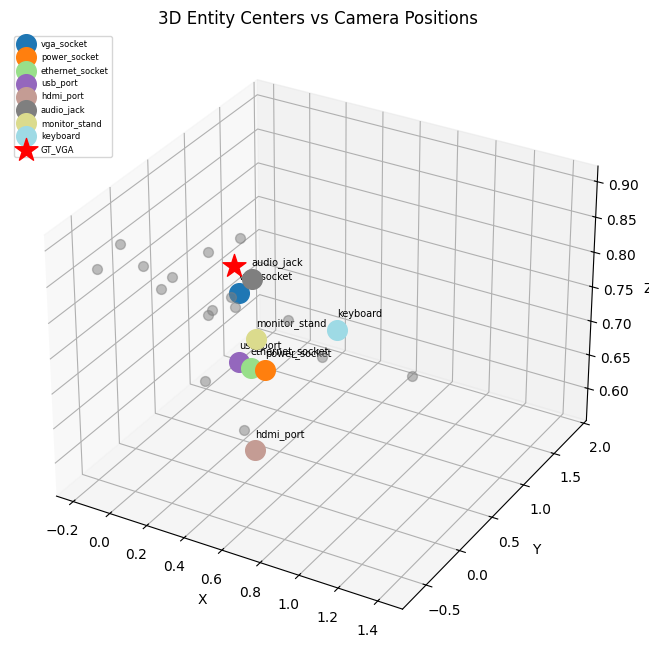

Saved 3d_verification.png


In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D

with open("/kaggle/working/FINAL_SUBMISSION.json") as f:
    results = json.load(f)

GT_VGA_C = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab20(np.linspace(0, 1, len(results)))
for i, r in enumerate(results):
    c = np.array(r["obb"]["center"])
    ax.scatter(*c, s=200, color=colors[i], label=r["entity"], zorder=5)
    ax.text(c[0], c[1], c[2]+0.02, r["entity"], fontsize=7)

# Plot GT VGA
ax.scatter(*GT_VGA_C, s=300, color='red', marker='*', label='GT_VGA', zorder=6)

# Plot camera positions
for pos in cam_positions:
    ax.scatter(*pos, s=50, color='gray', alpha=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(loc='upper left', fontsize=6)
plt.title('3D Entity Centers vs Camera Positions')
plt.savefig('/kaggle/working/3d_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 3d_verification.png")